[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brianjalaian/CAP6606_ML_ISR/blob/main/modules/14_rnn/ch15-UWFLectureCode.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/brianjalaian/CAP6606_ML_ISR/blob/main/modules/14_rnn/ch15-UWFLectureCode.ipynb)


# Chapter 15 - Recurrent Neural Networks (RNN)

In [2]:
import sys
sys.path.insert(0, '..')

In [3]:
from IPython.display import Image
%matplotlib inline

## Hidden-recurrence vs. output-recurrence

Using the `torch.nn` module, a recurrent layer can be defined via RNN, which is similar to the **hidden-to-hidden** recurrence. Create the layer and assign the weights and biases for our manual computations:

In [4]:
import torch
import torch.nn as nn

torch.manual_seed(1)

rnn_layer = nn.RNN(input_size=5, hidden_size=2, num_layers=1, batch_first=True) 

w_xh = rnn_layer.weight_ih_l0
w_hh = rnn_layer.weight_hh_l0
b_xh = rnn_layer.bias_ih_l0
b_hh = rnn_layer.bias_hh_l0

print('W_xh shape:', w_xh.shape)
print('W_hh shape:', w_hh.shape)
print('b_xh shape:', b_xh.shape)
print('b_hh shape:', b_hh.shape)

W_xh shape: torch.Size([2, 5])
W_hh shape: torch.Size([2, 2])
b_xh shape: torch.Size([2])
b_hh shape: torch.Size([2])


The input shape for this layer is (`batch_size, sequence_length, 5`), which is (`1,3,5`) in the following code, where the first dimension is the batch dimension (as we set `batch_first=True`), the second dimension corresponds to the sequence, and the last dimension corresponds to the features. Notice that we will output a sequence, which, for an input sequence of length 3 , will result in the output sequence $\left\langle\boldsymbol{o}^{(0)}, \boldsymbol{o}^{(1)}, \boldsymbol{o}^{(2)}\right\rangle$. Also, RNN uses one layer by default, and you can set `num_layers` to stack multiple RNN layers together to form a stacked RNN.

Now, we will call the forward pass on the `rnn_layer` and **manually compute** the outputs at each time step and compare them. The results show that `Output (manual)` and `RNN output` are the same.

In [5]:
x_seq = torch.tensor([[1.0]*5, [2.0]*5, [3.0]*5]).float()

## output of the simple RNN:
output, hn = rnn_layer(torch.reshape(x_seq, (1, 3, 5)))

## manually computing the output:
out_man = []
for t in range(3):
    xt = torch.reshape(x_seq[t], (1, 5))
    print(f'Time step {t} =>')
    print('   Input           :', xt.numpy())
    
    ht = torch.matmul(xt, torch.transpose(w_xh, 0, 1)) + b_xh    
    print('   Hidden          :', ht.detach().numpy())
    
    if t>0:
        prev_h = out_man[t-1]
    else:
        prev_h = torch.zeros((ht.shape))

    ot = ht + torch.matmul(prev_h, torch.transpose(w_hh, 0, 1)) + b_hh
    ot = torch.tanh(ot)
    out_man.append(ot)
    print('   Output (manual) :', ot.detach().numpy())
    print('   RNN output      :', output[:, t].detach().numpy())
    print()

Time step 0 =>
   Input           : [[1. 1. 1. 1. 1.]]
   Hidden          : [[-0.4701929   0.58639044]]
   Output (manual) : [[-0.3519801   0.52525216]]
   RNN output      : [[-0.35198015  0.52525216]]

Time step 1 =>
   Input           : [[2. 2. 2. 2. 2.]]
   Hidden          : [[-0.88883156  1.2364398 ]]
   Output (manual) : [[-0.68424344  0.76074266]]
   RNN output      : [[-0.68424344  0.76074266]]

Time step 2 =>
   Input           : [[3. 3. 3. 3. 3.]]
   Hidden          : [[-1.3074702  1.8864892]]
   Output (manual) : [[-0.8649416  0.9046636]]
   RNN output      : [[-0.8649416   0.90466356]]



<br>
<br>

---

## Implementing RNNs for sequence modeling in PyTorch
We are going to apply RNNs to two common problem tasks in project 1 and 2:  
1. Sentiment analysis  
2. Language modeling



In [6]:
import torch
import torch.nn as nn

In [7]:
# !pip install torchtext==0.10.0

**Attention**: To reproduce the code in the books, please make sure to use torchtext 0.10.0 (see https://pypi.org/project/torchtext/0.10.0/), which is the package I used for this chapter. 

There are a few adjustments in this notebooks that also make it compatible to newer versions of torchtext.

For newer versions of torchtext, installing portalocker may be necessary:

In [8]:
# !pip install torchtext

In [9]:
# !pip install portalocker


### Project 1: Predicting the sentiment of IMDb movie reviews


### Preparing the movie review data
Each sample of the datasets consists of two elements, the sentiment label representing the target label we want to predict (`neg` refers to negative sentiment and `pos` refers to positive sentiment), and the movie review text (the input features). The text component of these movie reviews is sequences of words, and the RNN model classifies each sequence as a positive (1) or negative (0) review.

In [10]:
from torchtext.datasets import IMDB
from torch.utils.data.dataset import random_split

# Step 1: load and create the datasets

train_dataset = IMDB(split='train')
test_dataset = IMDB(split='test')

test_dataset = list(test_dataset)   #datapipe to list

torch.manual_seed(1)
train_dataset, valid_dataset = random_split(
    list(train_dataset), [20000, 5000])


In [11]:
## Step 2: find unique tokens (words)
import re
from collections import Counter, OrderedDict

token_counts = Counter() # collect the unique word frequencies

def tokenizer(text):
    # removes HTML markups as well as punctuation and other non-letter characters
    text = re.sub('<[^>]*>', '', text)
    emoticons = re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)', text.lower())
    text = re.sub('[\W]+', ' ', text.lower()) +\
        ' '.join(emoticons).replace('-', '')
    tokenized = text.split()
    return tokenized


for label, line in train_dataset:
    tokens = tokenizer(line)
    token_counts.update(tokens)
 
    
print('Vocab-size:', len(token_counts))

Vocab-size: 69023


Note that there might be some tokens in the validation or testing data that are not present in the training data and are thus not included in the mapping. If we have `q` tokens (that is, the size of `token_counts` passed to `Vocab`, which in this case is 69,023), then all tokens that haven’t been seen before, and are thus not included in `token_counts`, will be assigned the integer `1` (a placeholder for the unknown token). In other words, the index 1 is reserved for unknown words. Another reserved value is the integer `0`, which serves as a placeholder, a so-called padding token, for adjusting the sequence length. Later, when we are building an RNN model in PyTorch, we will consider this placeholder, 0, in more detail.

In [12]:
## Step 3: encoding each unique token into integers
from torchtext.vocab import vocab

sorted_by_freq_tuples = sorted(token_counts.items(), key=lambda x: x[1], reverse=True)
ordered_dict = OrderedDict(sorted_by_freq_tuples)

vocab = vocab(ordered_dict)

vocab.insert_token("<pad>", 0)
vocab.insert_token("<unk>", 1)
vocab.set_default_index(1)

print([vocab[token] for token in ['this', 'is', 'an', 'example', 'and', 'this', 'is', 'a', 'test']])

[11, 7, 35, 457, 3, 11, 7, 4, 2297]


In [13]:
if not torch.cuda.is_available():
    print("Warning: this code may be very slow on CPU")

In [14]:
## Step 3-A: define the functions for transformation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

text_pipeline = lambda x: [vocab[token] for token in tokenizer(x)] # tokenizer() is defined in Step 2 # vocab[] is defined in Step 3

from torchtext import __version__ as torchtext_version
from pkg_resources import parse_version

# if parse_version(torchtext.__version__) > parse_version("0.10"):
#     label_pipeline = lambda x: 1. if x == 2 else 0.         # 1 ~ negative, 2 ~ positive review
# else:
#     label_pipeline = lambda x: 1. if x == 'pos' else 0.

label_pipeline = lambda x: 1. if x == 2 else 0.         # 1 ~ negative, 2 ~ positive review


## Step 3-B: wrap the encode and transformation function
def collate_batch(batch):
    label_list, text_list, lengths = [], [], []
    for _label, _text in batch:
        label_list.append(label_pipeline(_label))
        processed_text = torch.tensor(text_pipeline(_text),
                                      dtype=torch.int64) # text_pipeline() is defined in Step 3-A
        text_list.append(processed_text)
        lengths.append(processed_text.size(0))
    label_list = torch.tensor(label_list)
    lengths = torch.tensor(lengths)
    
    padded_text_list = nn.utils.rnn.pad_sequence(
        text_list, batch_first=True) # pad_sequence(): all the sequences in a mini-batch have the same length to store them efficiently in a tensor
    return padded_text_list.to(device), label_list.to(device), lengths.to(device)

In [15]:
## Take a small batch for testing and see how it works

from torch.utils.data import DataLoader
dataloader = DataLoader(train_dataset, batch_size=4, shuffle=False, collate_fn=collate_batch)
text_batch, label_batch, length_batch = next(iter(dataloader))
print(text_batch)
print(label_batch) # batch of labels (4 samples labels in this case)
print(length_batch) # length of each sample (e.g., 165 for the first sample) # Other samples will be padded to the max length, which is 218 in this case
print(text_batch.shape)

tensor([[   35,  1739,     7,   449,   721,     6,   301,     4,   787,     9,
             4,    18,    44,     2,  1705,  2460,   186,    25,     7,    24,
           100,  1874,  1739,    25,     7, 34415,  3568,  1103,  7517,   787,
             5,     2,  4991, 12401,    36,     7,   148,   111,   939,     6,
         11598,     2,   172,   135,    62,    25,  3199,  1602,     3,   928,
          1500,     9,     6,  4601,     2,   155,    36,    14,   274,     4,
         42945,     9,  4991,     3,    14, 10296,    34,  3568,     8,    51,
           148,    30,     2,    58,    16,    11,  1893,   125,     6,   420,
          1214,    27, 14542,   940,    11,     7,    29,   951,    18,    17,
         15994,   459,    34,  2480, 15211,  3713,     2,   840,  3200,     9,
          3568,    13,   107,     9,   175,    94,    25,    51, 10297,  1796,
            27,   712,    16,     2,   220,    17,     4,    54,   722,   238,
           395,     2,   787,    32,    27,  5236,  

In [16]:
## Step 4: batching the datasets

batch_size = 32  

train_dl = DataLoader(train_dataset, batch_size=batch_size,
                      shuffle=True, collate_fn=collate_batch)
valid_dl = DataLoader(valid_dataset, batch_size=batch_size,
                      shuffle=False, collate_fn=collate_batch)
test_dl = DataLoader(test_dataset, batch_size=batch_size,
                     shuffle=False, collate_fn=collate_batch)

### Embedding layers for sentence encoding

**Why Not Use One-Hot Encoding?**
1.	Large Dimensionality
	- One-hot encoding maps each word to a vector of size equal to the vocabulary size.
	- With vocabulary sizes in the range of $10^4 - 10^5$, the number of input features becomes extremely large.
	- This high dimensionality increases computational cost and memory usage.
2.	Curse of Dimensionality
	- Training a model with such high-dimensional input features can lead to inefficiencies.
	- The model may struggle to generalize well due to sparse feature representation.
3.	Sparsity Issue
	- One-hot encoded vectors contain mostly zeros, with only a single one per word.
	- This results in inefficient memory storage and computation.

Thus, alternative embedding methods (e.g., word embeddings) are preferred to reduce dimensionality and capture meaningful relationships between words.

**Embedding methods**

### **Word Embeddings: An Alternative to One-Hot Encoding**
1. **Concept of Embeddings**
   - Instead of using one-hot encoding, each word is mapped to a vector of fixed size with **real-valued elements**.
   - Unlike one-hot encoded vectors, embeddings can represent an **infinite number of real numbers** within a finite-sized vector.
   - Theoretically, real numbers can be extracted from a continuous interval (e.g., $[-1,1]$).
2. **Feature Learning with Embeddings**
   - Embeddings allow for automatic learning of **salient features** to represent words in the dataset.
   - The embedding dimension is chosen such that: $\text{embedding\_dim} \ll n_{\text{words}}$, where $n_{\text{words}}$ is the vocabulary size.
3. **Embedding Matrix Structure**
   - Given a token set of size $n + 2$:
     - $n$: Size of the token vocabulary.
     - **Index 0**: Reserved for padding.
     - **Index 1**: Used for unknown words.
   - The embedding matrix has a shape: $(n + 2) \times \text{embedding\_dim}$
   - Each **row** in this matrix represents the learned numerical features for a token.
   - When an integer index $i$ is input, it retrieves the corresponding **row** from the matrix.

4. **Implementation in Practice**
   - The embedding matrix serves as the **input layer** for neural network models.
   - In PyTorch, an embedding layer can be created using:
     ```python
     nn.Embedding(num_embeddings=n+2, embedding_dim=embedding_dim)
     ```

 * `input_dim`: Total number of unique words (vocabulary size) plus reserved indices (padding and unknown words).
 * `output_dim`: Size of each word’s embedding vector (also called the embedding dimension). This must be explicitly set and is much smaller than `input_dim` to reduce dimensionality.
 * `input_length`: Length of the input sequence (padded if necessary).
    * for example, `'This is an example' -> [0, 0, 0, 0, 0, 0, 3, 1, 8, 9]`   
    => `input_length` is 10
 
 

 * When calling the layer, takes integer values as input, the embedding layer convert each interger into float vector of size `[output_dim]`
   * If input shape is `[BATCH_SIZE]`, output shape will be `[BATCH_SIZE, output_dim]`
   * If input shape is `[BATCH_SIZE, input_length]`, output shape will be `[BATCH_SIZE, input_length, output_dim]`

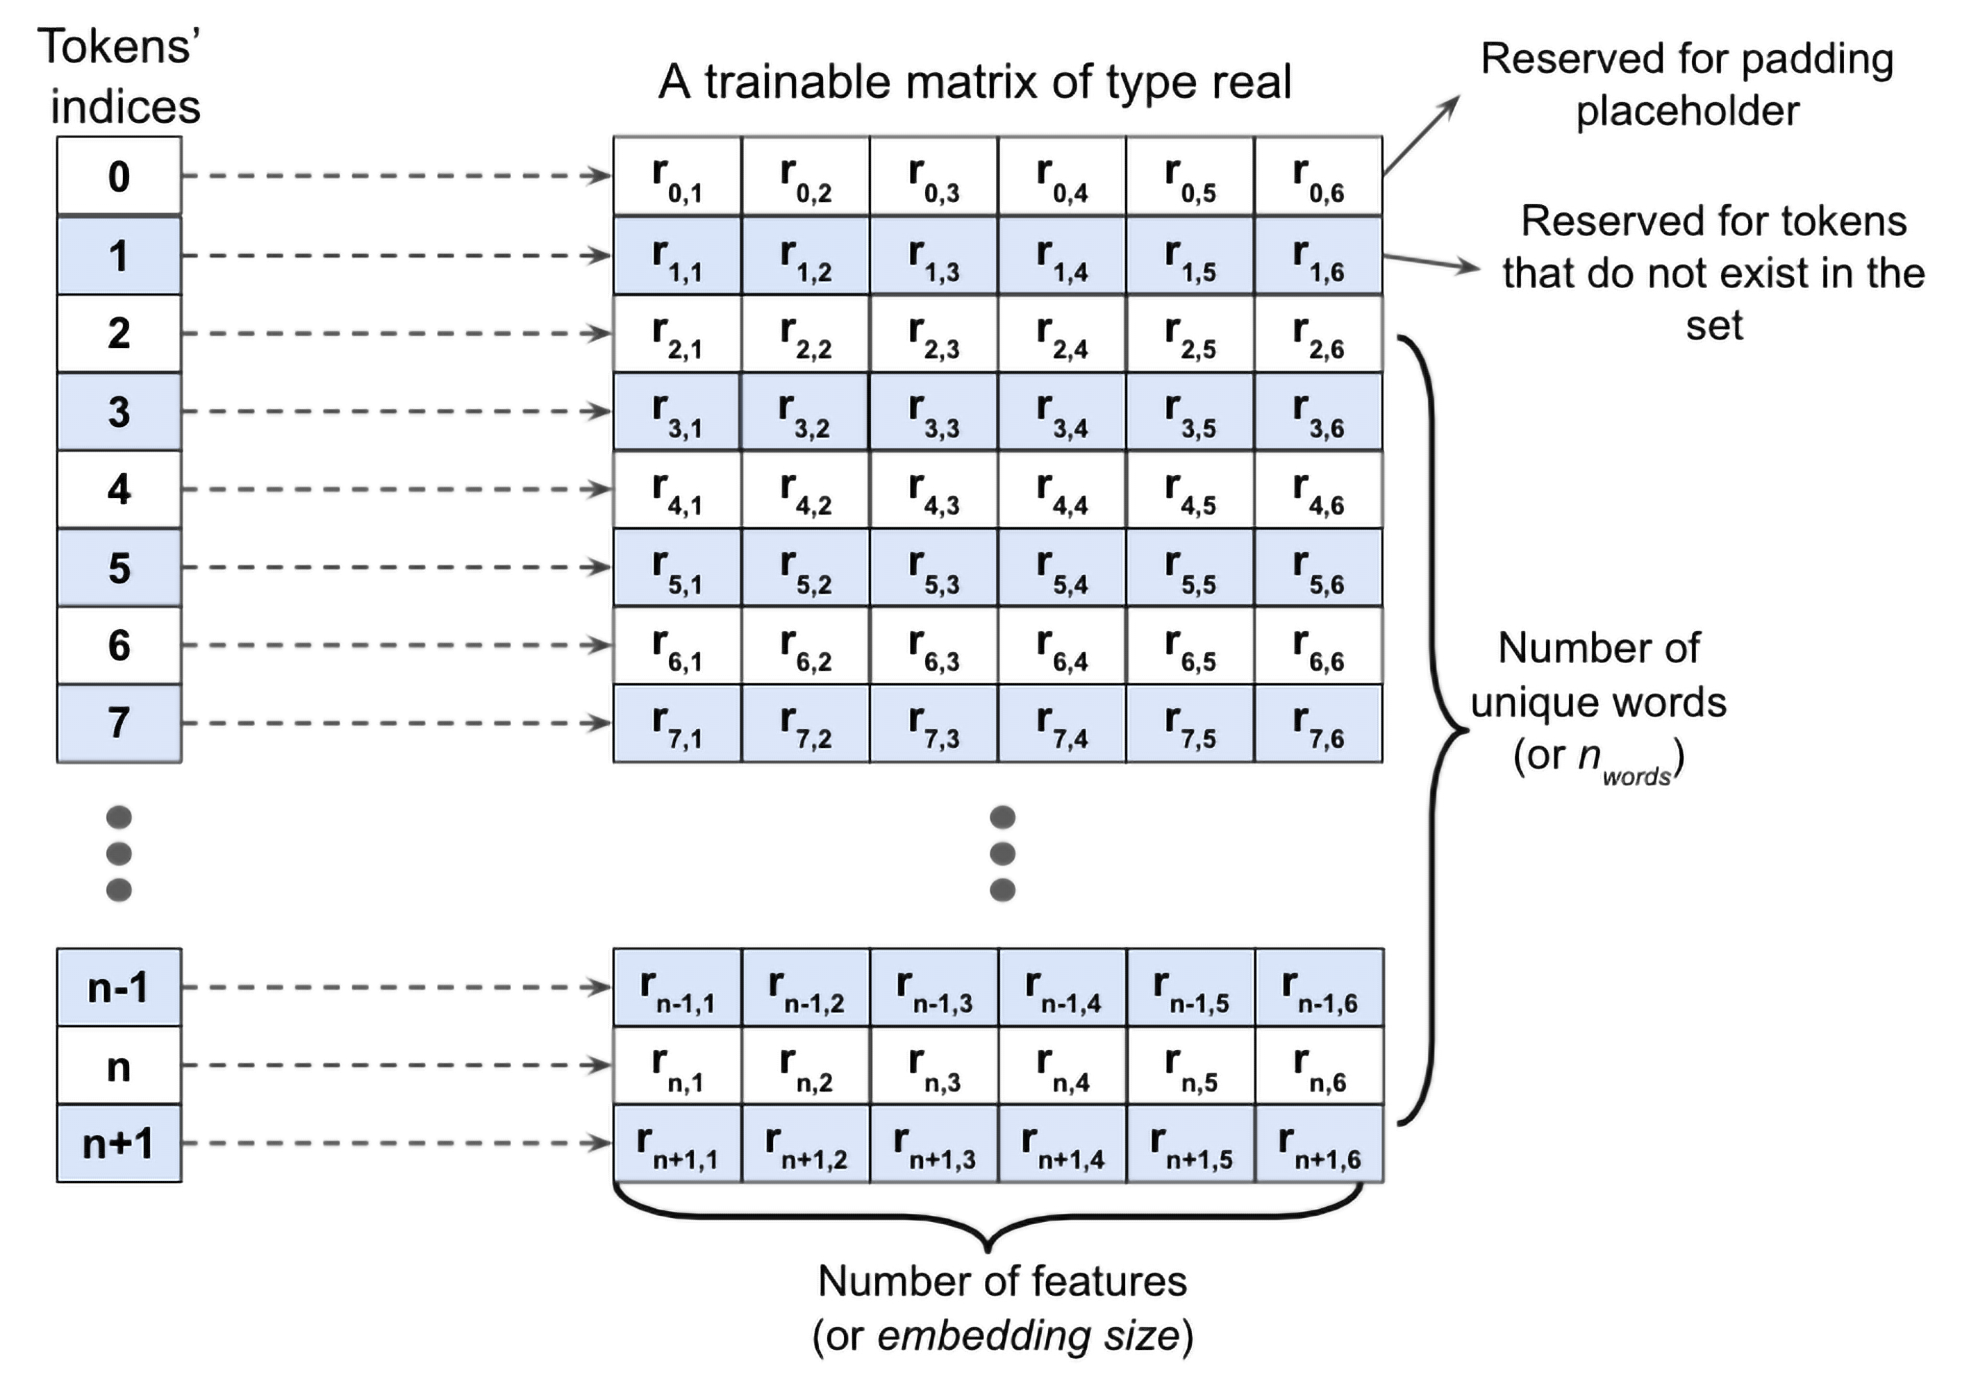

In [17]:
Image(filename='figures/15_10.png', width=600)

In [18]:
embedding = nn.Embedding(num_embeddings=10, 
                         embedding_dim=3, 
                         padding_idx=0)
 
# a batch of 2 samples of 4 indices each
text_encoded_input = torch.LongTensor([[1,2,4,5],[4,3,2,0]])
print(embedding(text_encoded_input))


tensor([[[ 0.7039, -0.8321, -0.4651],
         [-0.3203,  2.2408,  0.5566],
         [-0.4643,  0.3046,  0.7046],
         [-0.7106, -0.2959,  0.8356]],

        [[-0.4643,  0.3046,  0.7046],
         [ 0.0946, -0.3531,  0.9124],
         [-0.3203,  2.2408,  0.5566],
         [ 0.0000,  0.0000,  0.0000]]], grad_fn=<EmbeddingBackward0>)


### Building an RNN model

* **RNN layers:**
  * `nn.RNN(input_size, hidden_size, num_layers=1)`: A regular RNN layer, that is, a fully connected recurrent layer.
  * `nn.LSTM(..)`: A long short-term memory RNN, which is useful for capturing the long-term dependencies.
  * `nn.GRU(..)`: A recurrent layer with a gated recurrent unit.
  * `nn.RNN(input_size, hidden_size, num_layers=1, bidirectional=True)`
 

In [19]:
## An example of building a RNN model
## with simple RNN layer

# Fully connected neural network with one hidden layer
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(input_size, 
                          hidden_size, 
                          num_layers=2, 
                          batch_first=True)
        #self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        #self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        _, hidden = self.rnn(x)
        out = hidden[-1, :, :] # take the last hidden state from the last layer as the input to the fully connected layer
        out = self.fc(out) # a non-recurrent fully connected layer as the output layer
        return out

model = RNN(64, 32) 

print(model) 
 
model(torch.randn(5, 3, 64)) 

RNN(
  (rnn): RNN(64, 32, num_layers=2, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


tensor([[ 0.3183],
        [ 0.1230],
        [ 0.1772],
        [-0.1052],
        [-0.1259]], grad_fn=<AddmmBackward0>)

### Building an RNN model for the sentiment analysis task
Since we have very long sequences, we are going to use an LSTM layer to account for long-range effects. We will create an RNN model for sentiment analysis. You may change self.rnn from LSTM to regular RNN, you will observe the performance drops because regular RNN might not able to capture well on long-range data. 


In [20]:
class RNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, rnn_hidden_size, fc_hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 
                                      embed_dim, 
                                      padding_idx=0) 
        self.rnn = nn.LSTM(embed_dim, rnn_hidden_size, 
                           batch_first=True)
        self.fc1 = nn.Linear(rnn_hidden_size, fc_hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, text, lengths):
        out = self.embedding(text)
        out = nn.utils.rnn.pack_padded_sequence(out, lengths.cpu().numpy(), enforce_sorted=False, batch_first=True)
        out, (hidden, cell) = self.rnn(out)
        out = hidden[-1, :, :]
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out
         
vocab_size = len(vocab)
embed_dim = 20 # embeddings of feature size 20
rnn_hidden_size = 64
fc_hidden_size = 64

torch.manual_seed(1)
model = RNN(vocab_size, embed_dim, rnn_hidden_size, fc_hidden_size) 
model = model.to(device)

In [21]:
def train(dataloader):
    model.train()
    total_acc, total_loss = 0, 0
    for text_batch, label_batch, lengths in dataloader:
        optimizer.zero_grad()
        pred = model(text_batch, lengths)[:, 0]
        loss = loss_fn(pred, label_batch)
        loss.backward()
        optimizer.step()
        total_acc += ((pred>=0.5).float() == label_batch).float().sum().item()
        total_loss += loss.item()*label_batch.size(0)
    return total_acc/len(dataloader.dataset), total_loss/len(dataloader.dataset)
 
def evaluate(dataloader):
    model.eval()
    total_acc, total_loss = 0, 0
    with torch.no_grad():
        for text_batch, label_batch, lengths in dataloader:
            pred = model(text_batch, lengths)[:, 0]
            loss = loss_fn(pred, label_batch)
            total_acc += ((pred>=0.5).float() == label_batch).float().sum().item()
            total_loss += loss.item()*label_batch.size(0)
    return total_acc/len(dataloader.dataset), total_loss/len(dataloader.dataset)

In [22]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10 

torch.manual_seed(1)
 
for epoch in range(num_epochs):
    acc_train, loss_train = train(train_dl)
    acc_valid, loss_valid = evaluate(valid_dl)
    print(f'Epoch {epoch} accuracy: {acc_train:.4f} val_accuracy: {acc_valid:.4f}')
 

Epoch 0 accuracy: 0.5908 val_accuracy: 0.6596
Epoch 1 accuracy: 0.7154 val_accuracy: 0.6112
Epoch 2 accuracy: 0.6871 val_accuracy: 0.7304
Epoch 3 accuracy: 0.8082 val_accuracy: 0.8180
Epoch 4 accuracy: 0.8720 val_accuracy: 0.8430
Epoch 5 accuracy: 0.9087 val_accuracy: 0.8508
Epoch 6 accuracy: 0.9288 val_accuracy: 0.8352
Epoch 7 accuracy: 0.9459 val_accuracy: 0.8248
Epoch 8 accuracy: 0.9623 val_accuracy: 0.8678
Epoch 9 accuracy: 0.9698 val_accuracy: 0.8684


In [23]:
acc_test, _ = evaluate(test_dl)
print(f'test_accuracy: {acc_test:.4f}') 

test_accuracy: 0.8552


#### More on the bidirectional RNN

**Trying bidirectional recurrent layer**

The bidirectional RNN layer makes two passes over each input sequence: a forward pass and a reverse or backward pass (note that this is not to be confused with the forward and backward passes in the context of backpropagation). The resulting hidden states of these forward and backward passes are usually concatenated into a single hidden state. Other merge modes include summation, multiplication (multiplying the results of the two passes), and averaging (taking the average of the two).

In [24]:
class RNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, rnn_hidden_size, fc_hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, 
                                      embed_dim, 
                                      padding_idx=0) 
        self.rnn = nn.LSTM(embed_dim, rnn_hidden_size, 
                           batch_first=True, bidirectional=True)
        self.fc1 = nn.Linear(rnn_hidden_size*2, fc_hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(fc_hidden_size, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, text, lengths):
        out = self.embedding(text)
        out = nn.utils.rnn.pack_padded_sequence(out, lengths.cpu().numpy(), enforce_sorted=False, batch_first=True)
        _, (hidden, cell) = self.rnn(out)
        out = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out
    
torch.manual_seed(1)
model = RNN(vocab_size, embed_dim, rnn_hidden_size, fc_hidden_size) 
model = model.to(device)

In [25]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

num_epochs = 10 

torch.manual_seed(1)
 
for epoch in range(num_epochs):
    acc_train, loss_train = train(train_dl)
    acc_valid, loss_valid = evaluate(valid_dl)
    print(f'Epoch {epoch} accuracy: {acc_train:.4f} val_accuracy: {acc_valid:.4f}')

Epoch 0 accuracy: 0.6386 val_accuracy: 0.7114
Epoch 1 accuracy: 0.7897 val_accuracy: 0.8082
Epoch 2 accuracy: 0.8706 val_accuracy: 0.8380
Epoch 3 accuracy: 0.8833 val_accuracy: 0.8302
Epoch 4 accuracy: 0.9302 val_accuracy: 0.8580
Epoch 5 accuracy: 0.9496 val_accuracy: 0.8356
Epoch 6 accuracy: 0.9687 val_accuracy: 0.8584
Epoch 7 accuracy: 0.9805 val_accuracy: 0.8552
Epoch 8 accuracy: 0.9777 val_accuracy: 0.8590
Epoch 9 accuracy: 0.9824 val_accuracy: 0.8272


In [26]:
test_dataset = IMDB(split='test')
test_dl = DataLoader(test_dataset, batch_size=batch_size,
                     shuffle=False, collate_fn=collate_batch)

In [ ]:
acc_test, _ = evaluate(test_dl)
print(f'test_accuracy: {acc_test:.4f}') 

test_accuracy: 0.8566


---

## Project two: character-level language modeling in PyTorch
In the model that we will build now, the input is a text document, and our goal is to develop a model that can generate new text that is similar in style to the input document. Examples of such input are a book or a computer program in a specific programming language.

In character-level language modeling, the input is broken down into a sequence of characters that are fed into our network one character at a time. The network will process each new character in conjunction with the memory of the previously seen characters to predict the next one.

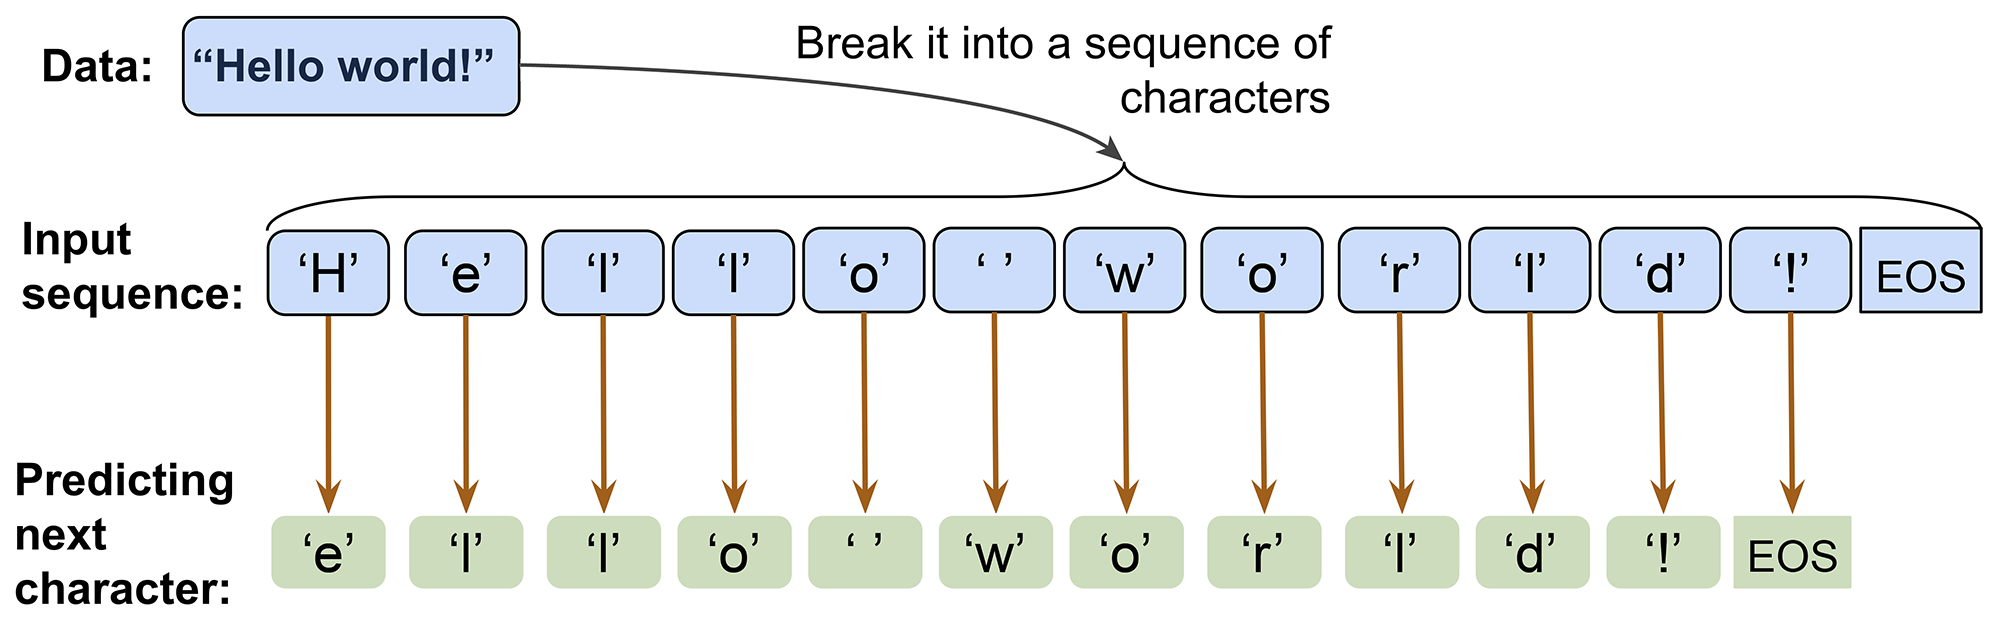

In [ ]:
Image(filename='figures/15_11.png', width=500)

### Preparing the dataset
To obtain the input data, visit the Project Gutenberg website at https://www.gutenberg.org/, which provides thousands of free e-books. For our example, you can download the book *The Mysterious Island*, by Jules Verne (published in 1874) in plain text format from https://www.gutenberg.org/files/1268/1268-0.txt.  Note that this link will take you directly to the download page. If you are using macOS or a Linux operating system, you can download the file with the following command in the terminal:

In [ ]:
# !curl -O https://www.gutenberg.org/files/1268/1268-0.txt

### Preprocessing the dataset

In [28]:
import numpy as np

## Reading and processing text
with open('1268-0.txt', 'r', encoding="utf8") as fp:
    text=fp.read()
    
start_indx = text.find('THE MYSTERIOUS ISLAND')
end_indx = text.find('End of the Project Gutenberg')

text = text[start_indx:end_indx]
char_set = set(text) # the set of unique characters observed in this text
print('Total Length:', len(text))
print('Unique Characters:', len(char_set))

Total Length: 1112350
Unique Characters: 80


Most NN libraries and RNN implementations cannot deal with input data in string format, which is why we have to convert the text into a numeric format. To do this, we will create a simple Python dictionary that maps each character to an integer, `char2int`. We will also need a reverse mapping to convert the results of our model back to text. Although the reverse can be done using a dictionary that associates integer keys with character values, using a NumPy array and indexing the array to map indices to those unique characters is more efficient.

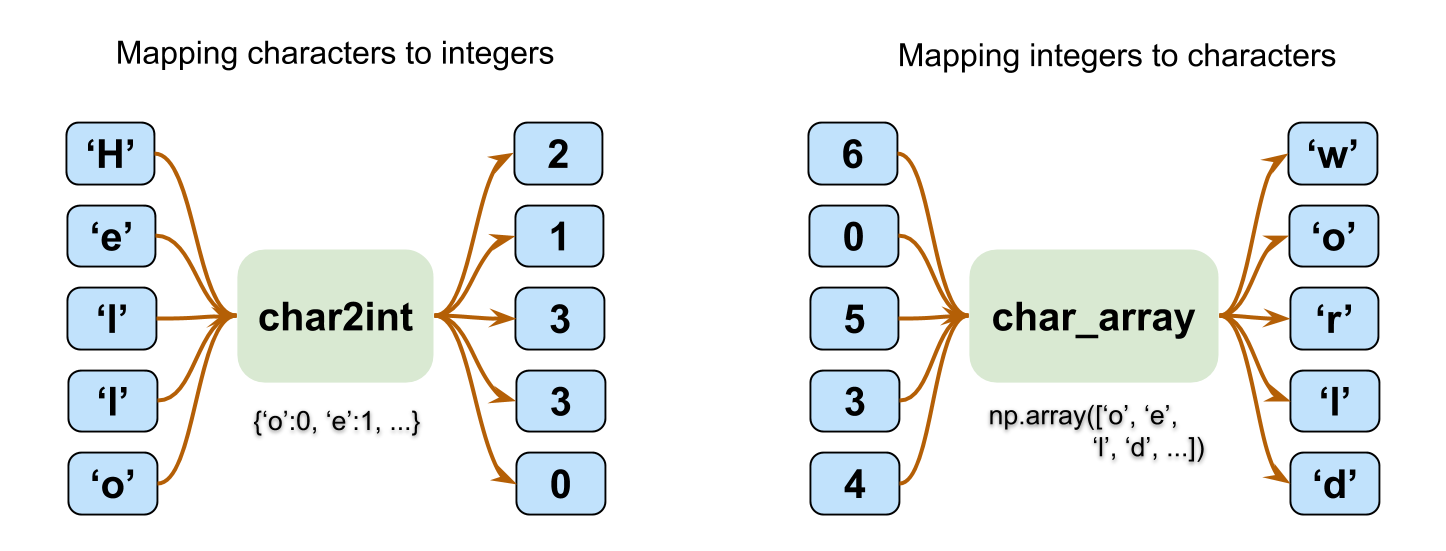

In [ ]:
Image(filename='figures/15_12.png', width=500)

Building the dictionary to map characters to integers, and reverse mapping via indexing a NumPy array. We can do it with the following code:

In [29]:
chars_sorted = sorted(char_set)
char2int = {ch:i for i,ch in enumerate(chars_sorted)}
char_array = np.array(chars_sorted)

# text_encoded array contains the encoded values for all the characters in the text
text_encoded = np.array(
    [char2int[ch] for ch in text],
    dtype=np.int32)

print('Text encoded shape: ', text_encoded.shape)

print(text[:15], '     == Encoding ==> ', text_encoded[:15])
print(text_encoded[15:21], ' == Reverse  ==> ', ''.join(char_array[text_encoded[15:21]]))

Text encoded shape:  (1112350,)
THE MYSTERIOUS       == Encoding ==>  [44 32 29  1 37 48 43 44 29 42 33 39 45 43  1]
[33 43 36 25 38 28]  == Reverse  ==>  ISLAND


In [30]:
for ex in text_encoded[:5]:
    print('{} -> {}'.format(ex, char_array[ex]))

44 -> T
32 -> H
29 -> E
1 ->  
37 -> M


Remember our goal is to design a model that can predict the next character of a given input sequence, where the input sequence represents an incomplete text. For example, after seeing “Deep Learn,” the model should predict “i” as the next character. **Given that we have 80 unique characters, this problem becomes a multiclass classification task.**

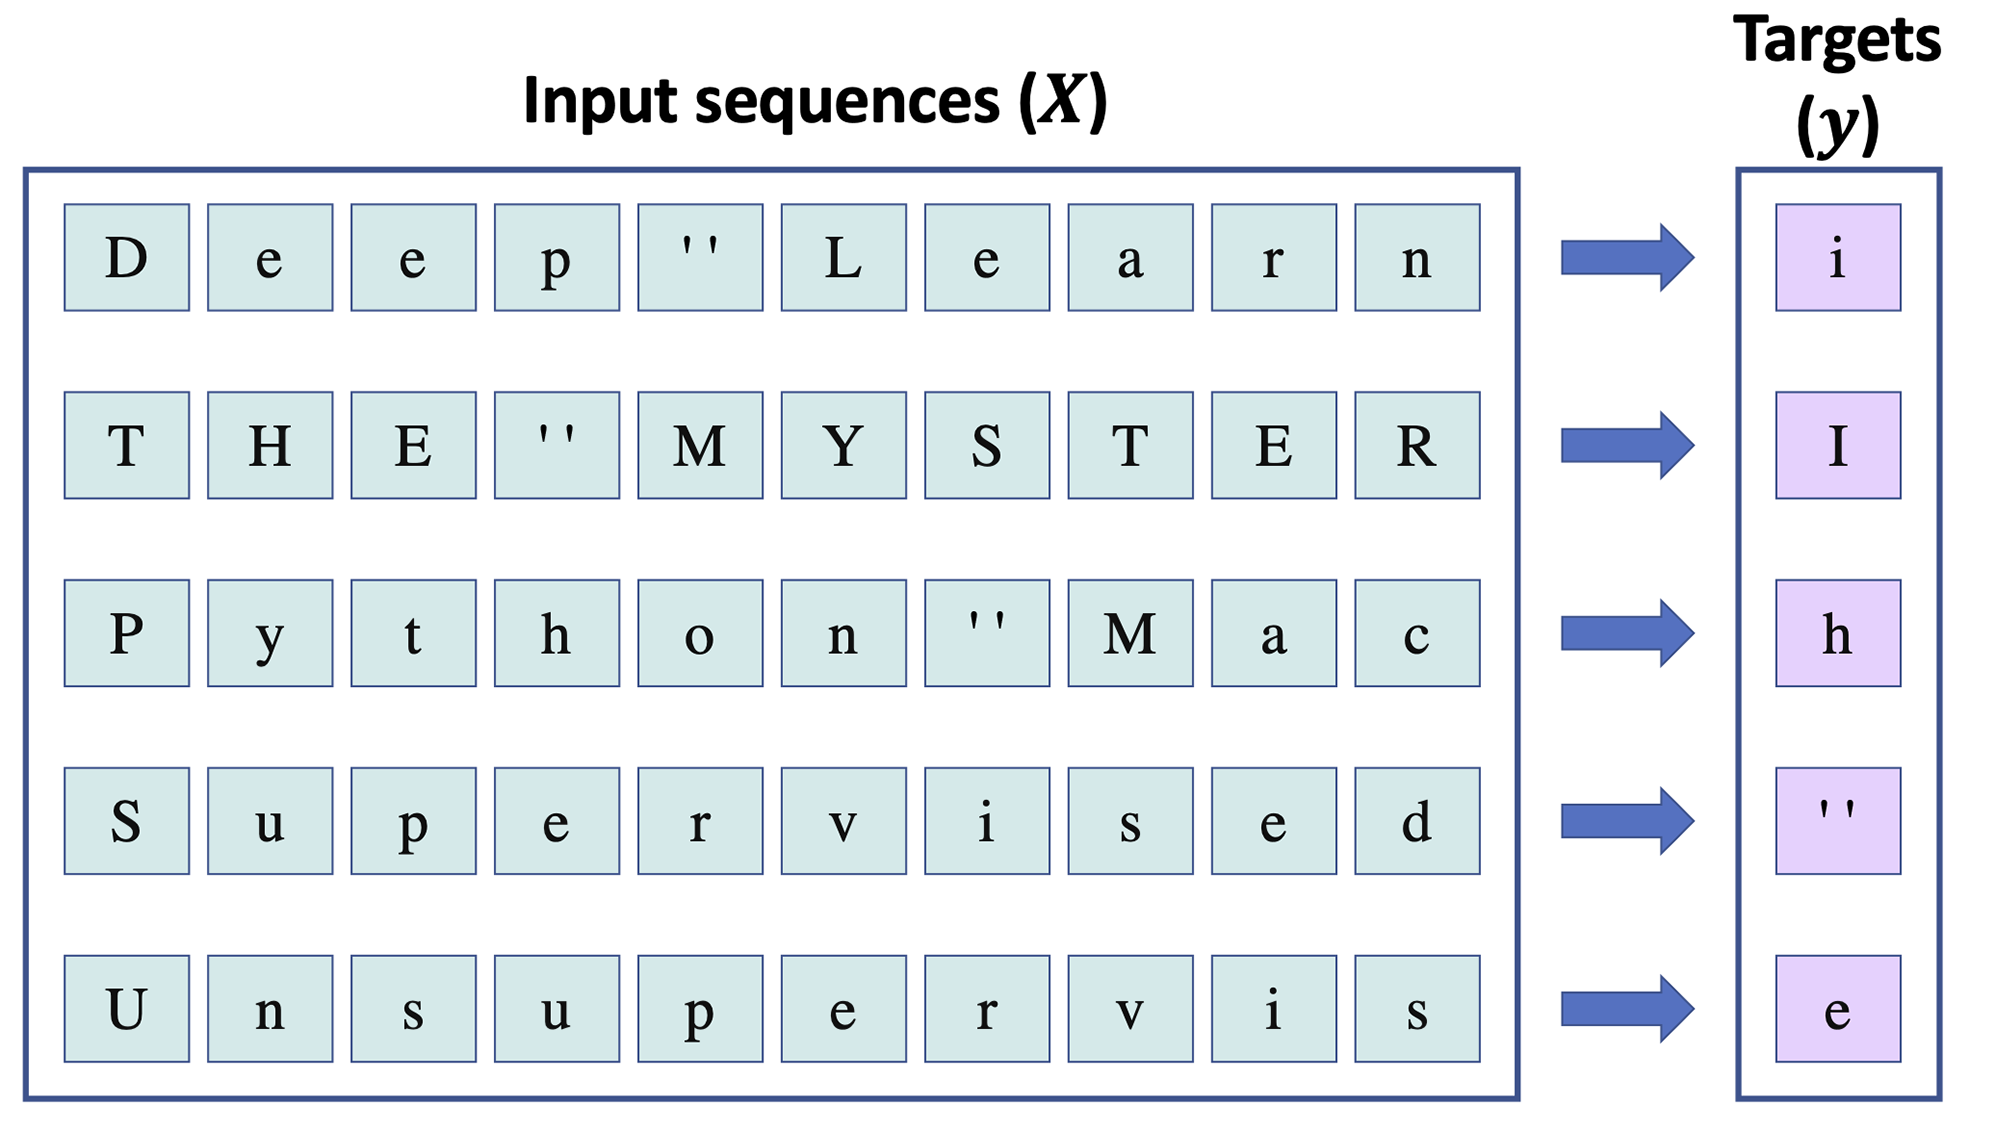

In [ ]:
Image(filename='figures/15_13.png', width=500)

Starting with a **sequence of length** 1 (that is, one single letter), we can iteratively generate new text based on this multiclass classification approach:

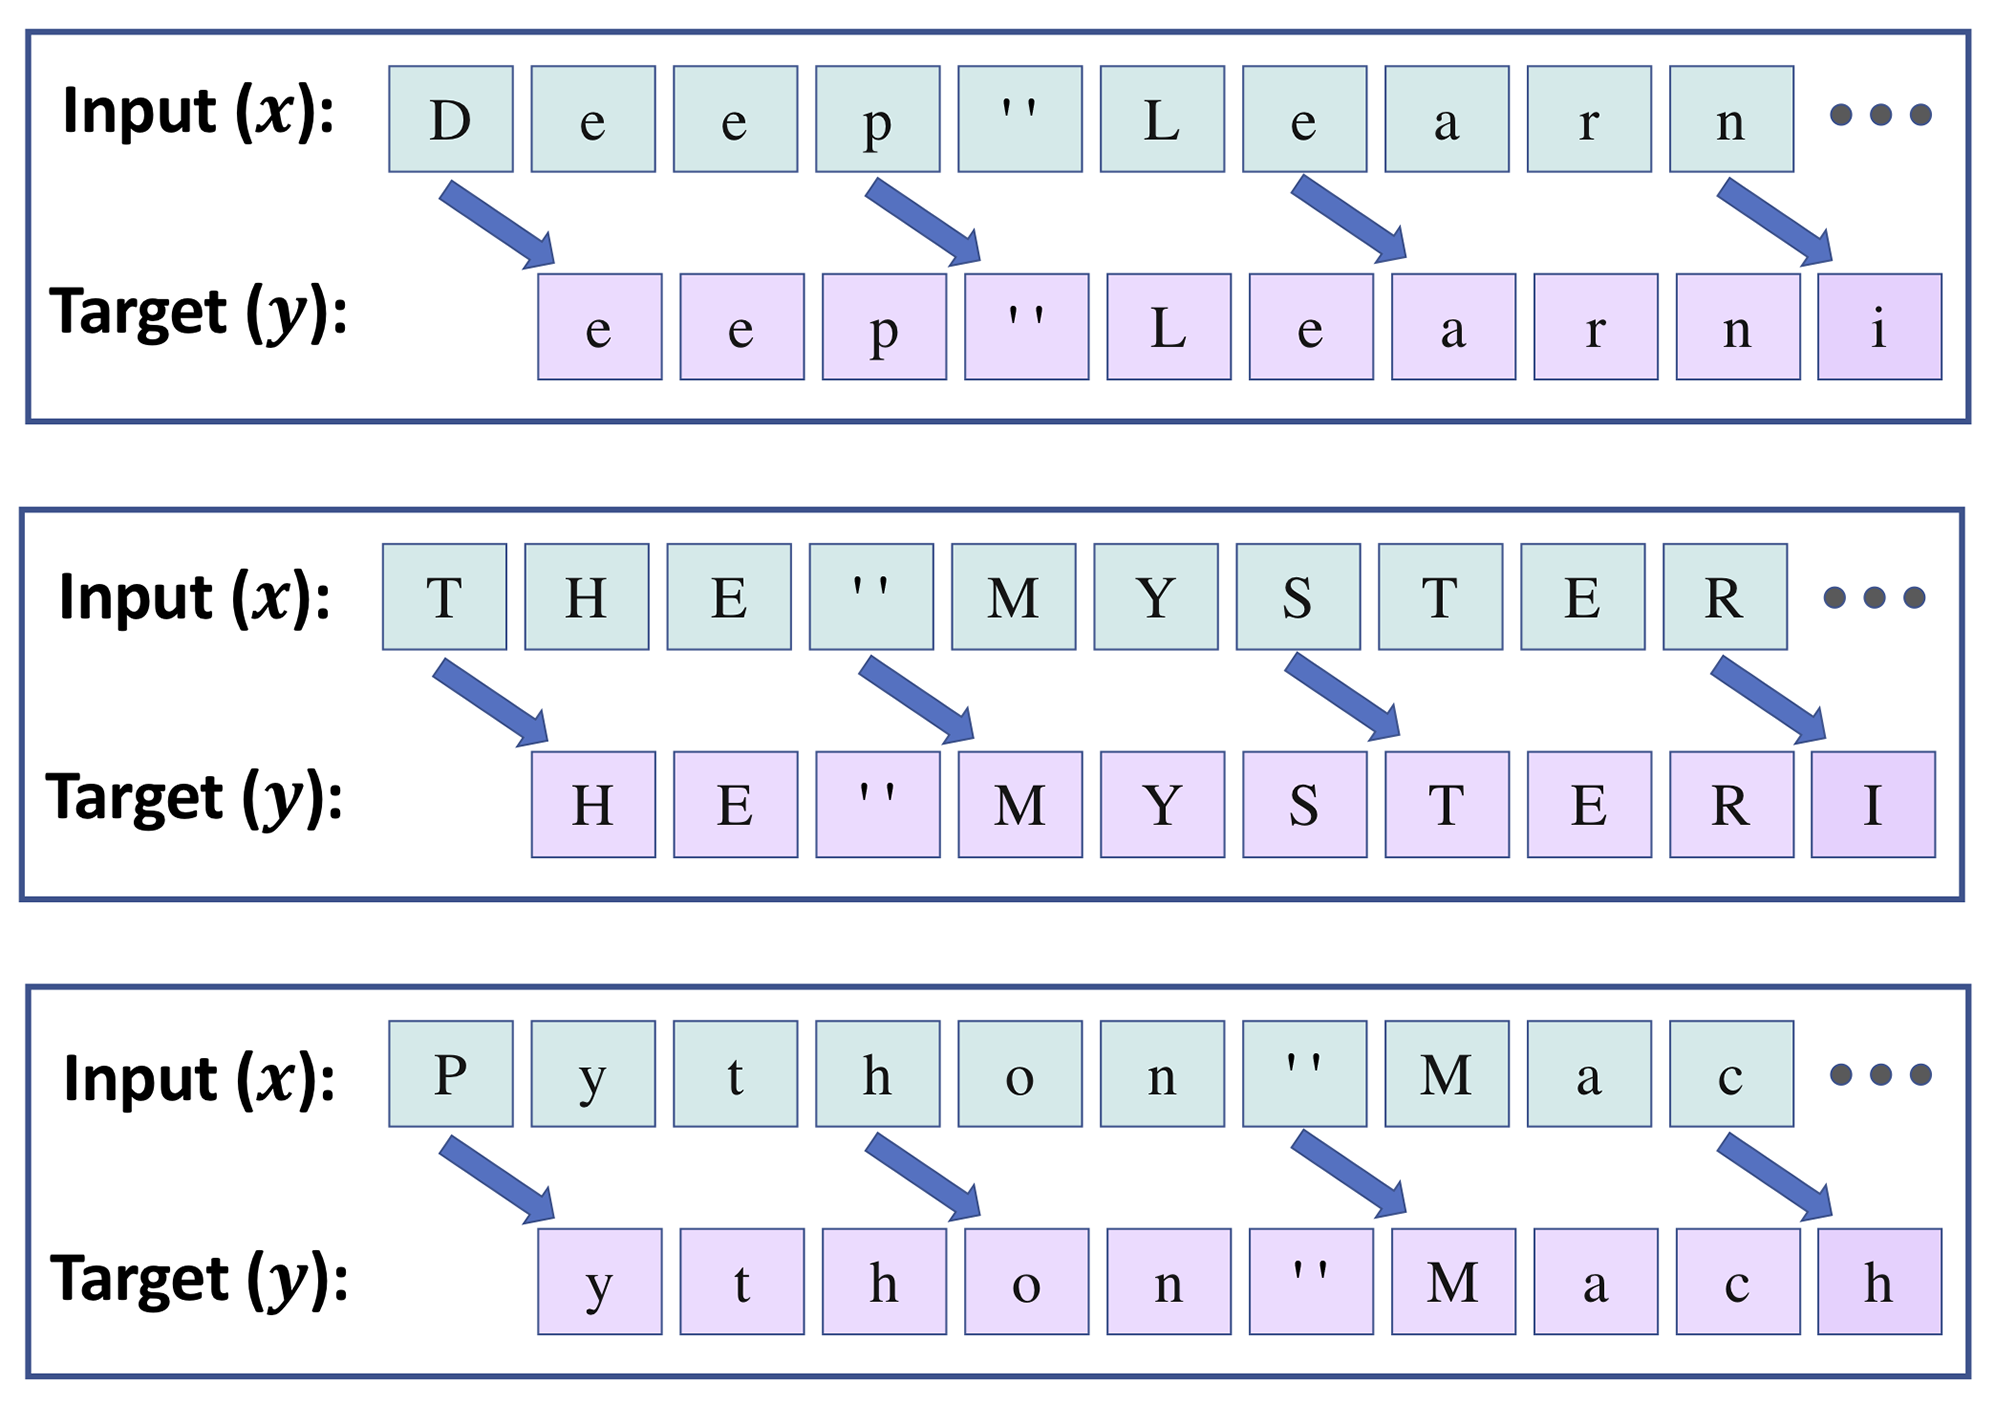

In [ ]:
Image(filename='figures/15_14.png', width=500)

In practice, the sequence length impacts the quality of the generated text. 
- Longer sequences can result in more meaningful sentences. 
- For shorter sequences, however, the model might focus on capturing individual words correctly, while ignoring the context for the most part.

Although longer sequences usually result in more meaningful sentences, as mentioned, for long sequences, the RNN model will have problems capturing long-range dependencies. Thus, in practice, finding a sweet spot and good value for the sequence length is a hyperparameter optimization problem.

In [31]:
seq_length = 40 # length of input sequence
chunk_size = seq_length + 1

text_chunks = [text_encoded[i:i+chunk_size] 
               for i in range(len(text_encoded)-chunk_size+1)] 

## inspection:
for seq in text_chunks[:1]:
    input_seq = seq[:seq_length]
    target = seq[seq_length] 
    print(input_seq, ' -> ', target)
    print(repr(''.join(char_array[input_seq])), 
          ' -> ', repr(''.join(char_array[target])))

[44 32 29  1 37 48 43 44 29 42 33 39 45 43  1 33 43 36 25 38 28  1  6  6
  6  0  0  0  0  0 40 67 64 53 70 52 54 53  1 51]  ->  74
'THE MYSTERIOUS ISLAND ***\n\n\n\n\nProduced b'  ->  'y'


We have already stored the entire encoded text in its original order in text_encoded. We will first create text chunks consisting of 41 characters each. We will further get rid of the last chunk if it is shorter than 41 characters. As a result, the new chunked dataset, named `text_chunks`, will always contain sequences of size 41 . The 41-character chunks will then be used to construct the sequence $x$ (that is, the input), as well as the sequence $y$ (that is, the target), both of which will have 40 elements. For instance, sequence $x$ will consist of the elements with indices $[0,1, \ldots, 39]$. Furthermore, since sequence $y$ will be shifted by one position with respect to $x$, its corresponding indices will be $[1,2, \ldots, 40]$. Then, we will transform the result into a Dataset object by applving a self-defined Dataset class:

In [32]:
import torch
from torch.utils.data import Dataset

class TextDataset(Dataset):
    def __init__(self, text_chunks):
        self.text_chunks = text_chunks

    def __len__(self):
        return len(self.text_chunks)
    
    def __getitem__(self, idx):
        text_chunk = self.text_chunks[idx]
        return text_chunk[:-1].long(), text_chunk[1:].long()
    
seq_dataset = TextDataset(torch.tensor(text_chunks))

/tmp/ipykernel_595431/2527503007.py:15: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:245.)
  seq_dataset = TextDataset(torch.tensor(text_chunks))


In [33]:
for i, (seq, target) in enumerate(seq_dataset):
    print(' Input (x):', repr(''.join(char_array[seq])))
    print('Target (y):', repr(''.join(char_array[target])))
    print()
    if i == 1:
        break
    

 Input (x): 'THE MYSTERIOUS ISLAND ***\n\n\n\n\nProduced b'
Target (y): 'HE MYSTERIOUS ISLAND ***\n\n\n\n\nProduced by'

 Input (x): 'HE MYSTERIOUS ISLAND ***\n\n\n\n\nProduced by'
Target (y): 'E MYSTERIOUS ISLAND ***\n\n\n\n\nProduced by '



In [34]:
device = torch.device("cuda:0")
# device = 'cpu'

In [35]:
from torch.utils.data import DataLoader
 
batch_size = 64

torch.manual_seed(1)
seq_dl = DataLoader(seq_dataset, batch_size=batch_size, shuffle=True, drop_last=True)


### Building a character-level RNN model

In [36]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, rnn_hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim) 
        self.rnn_hidden_size = rnn_hidden_size
        self.rnn = nn.LSTM(embed_dim, rnn_hidden_size, 
                           batch_first=True)
        self.fc = nn.Linear(rnn_hidden_size, vocab_size)

    def forward(self, x, hidden, cell):
        out = self.embedding(x).unsqueeze(1)
        out, (hidden, cell) = self.rnn(out, (hidden, cell))
        out = self.fc(out).reshape(out.size(0), -1)
        return out, hidden, cell

    def init_hidden(self, batch_size):
        hidden = torch.zeros(1, batch_size, self.rnn_hidden_size)
        cell = torch.zeros(1, batch_size, self.rnn_hidden_size)
        return hidden.to(device), cell.to(device)
    
vocab_size = len(char_array)
embed_dim = 256
rnn_hidden_size = 512

torch.manual_seed(1)
model = RNN(vocab_size, embed_dim, rnn_hidden_size) 
model = model.to(device)
model

RNN(
  (embedding): Embedding(80, 256)
  (rnn): LSTM(256, 512, batch_first=True)
  (fc): Linear(in_features=512, out_features=80, bias=True)
)

In [37]:
"""This takes around 30 minutes to run on a single A40 GPU"""

loss_fn = nn.CrossEntropyLoss() # for multiclass classification (we have vocab_size=80 classes)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

num_epochs = 10000 

torch.manual_seed(1)

for epoch in range(num_epochs):
    hidden, cell = model.init_hidden(batch_size)
    seq_batch, target_batch = next(iter(seq_dl))
    seq_batch = seq_batch.to(device)
    target_batch = target_batch.to(device)
    optimizer.zero_grad()
    loss = 0
    for c in range(seq_length):
        pred, hidden, cell = model(seq_batch[:, c], hidden, cell) 
        loss += loss_fn(pred, target_batch[:, c])
    loss.backward()
    optimizer.step()
    loss = loss.item()/seq_length
    if epoch % 500 == 0:
        print(f'Epoch {epoch} loss: {loss:.4f}')
 

Epoch 0 loss: 4.3722
Epoch 500 loss: 1.3905
Epoch 1000 loss: 1.3410
Epoch 1500 loss: 1.2183
Epoch 2000 loss: 1.2261
Epoch 2500 loss: 1.1993
Epoch 3000 loss: 1.1510
Epoch 3500 loss: 1.1376
Epoch 4000 loss: 1.1863
Epoch 4500 loss: 1.1514
Epoch 5000 loss: 1.0877
Epoch 5500 loss: 1.1253
Epoch 6000 loss: 1.1545
Epoch 6500 loss: 1.1262
Epoch 7000 loss: 1.1061
Epoch 7500 loss: 1.1627
Epoch 8000 loss: 1.1322
Epoch 8500 loss: 1.1490
Epoch 9000 loss: 1.1052
Epoch 9500 loss: 1.1162


### Evaluation phase: generating new text passages

The RNN model we trained in the previous section returns the logits of size 80 for each unique character. These logits can be readily converted to probabilities, via the softmax function, that a particular character will be encountered as the next character. To predict the next character in the sequence, we can simply select the element with the maximum logit value, which is equivalent to selecting the character with the highest probability. However, instead of always selecting the character with the highest likelihood, we want to (randomly) sample from the outputs; otherwise, the model will always produce the same text. PyTorch already provides a class, `torch.distributions.categorical.Categorical`, which we can use to draw random samples from a categorical distribution. 

To see how this works, let’s generate some random samples from three categories $[0, 1, 2]$, with input logits $[1, 1, 1]$: As you can see, with the given logits, the categories have the same probabilities (that is, equiprobable categories). Therefore, if we use a large sample size (num_samples $\rightarrow \infty$), we would expect the number of occurrences of each category to reach $\approx 1 / 3$ of the sample size. 

In [ ]:
from torch.distributions.categorical import Categorical

torch.manual_seed(1)

logits = torch.tensor([[1.0, 1.0, 1.0]])

print('Probabilities:', nn.functional.softmax(logits, dim=1).numpy()[0])

m = Categorical(logits=logits)
samples = m.sample((10,))
 
print(samples.numpy())

Probabilities: [0.33333334 0.33333334 0.33333334]
[[0]
 [0]
 [0]
 [0]
 [1]
 [0]
 [1]
 [2]
 [1]
 [1]]


If we change the logits to $[1,1,3]$, then we would expect to observe more occurrences for category 2 (when a very large number of examples are drawn from this distribution):

In [ ]:
torch.manual_seed(1)

logits = torch.tensor([[1.0, 1.0, 3.0]])

print('Probabilities:', nn.functional.softmax(logits, dim=1).numpy()[0])

m = Categorical(logits=logits)
samples = m.sample((10,))
 
print(samples.numpy())

Probabilities: [0.10650698 0.10650698 0.78698605]
[[0]
 [2]
 [2]
 [1]
 [2]
 [1]
 [2]
 [2]
 [2]
 [2]]


We then define a function, `sample()`, that receives a short starting string, `starting_str`, and generate a new string, `generated_str`, which is initially set to the input string. `starting_str` is encoded to a sequence of integers, `encoded_input`. `encoded_input` is passed to the RNN model one character at a time to update the hidden states. The last character of `encoded_input` is passed to the model to generate a new character. Note that the output of the RNN model represents the logits (here, a vector of size 80 , which is the total number of possible characters) for the next character after observing the input sequence by the model.

Here, we only use the logits output (that is, $o^{(7)}$ ), which is passed to the `Categorical` class to generate a new sample. This new sample is converted to a character, which is then appended to the end of the generated string, `generated_text`, increasing its length by 1 . Then, this process is repeated until the length of the generated string reaches the desired value. The process of consuming the generated sequence as input for generating new elements is called **autoregression**.

In [ ]:
def sample(model, starting_str, 
           len_generated_text=500, 
           scale_factor=1.0):

    encoded_input = torch.tensor([char2int[s] for s in starting_str])
    encoded_input = torch.reshape(encoded_input, (1, -1))

    generated_str = starting_str

    model.eval()
    hidden, cell = model.init_hidden(1)
    hidden = hidden.to('cpu')
    cell = cell.to('cpu')
    for c in range(len(starting_str)-1):
        _, hidden, cell = model(encoded_input[:, c].view(1), hidden, cell) 
    
    last_char = encoded_input[:, -1]
    for i in range(len_generated_text):
        logits, hidden, cell = model(last_char.view(1), hidden, cell) 
        logits = torch.squeeze(logits, 0)
        scaled_logits = logits * scale_factor
        m = Categorical(logits=scaled_logits)
        last_char = m.sample()
        generated_str += str(char_array[last_char])
        
    return generated_str

torch.manual_seed(1)
model.to('cpu')
print(sample(model, starting_str='The island'))

The island had been neged to reward from them with denies he giving these gigant of some taking two years from the question has been employed without
consequences in his depth. As
to the notice beate can be vapor when there we must forgot.

“Shat’s likely,” said Pencroft.

“What a
region of Neption!” Cyrus Harding would have
been pushed their return to the shored him, to do in the dockyar and formation of the settlers’ animal which would be better dead of freshest.

Cyrus, was well presented by means of t


As you can see, the model generates mostly correct words, and, in some cases, the sentences are partially meaningful. You can further tune the training parameters, such as the length of input sequences for training, and the model architecture.

**Predictibility vs. randomness**

Furthermore, to control the predictability of the generated samples (that is, generating text following the learned patterns from the training text versus adding more randomness), the logits computed by the RNN model can be scaled before being passed to `Categorical` for sampling. The scaling factor, $\alpha$, can be interpreted as an analog to the temperature in physics. 
- Higher temperatures result in more entropy or randomness versus more predictable behavior at lower temperatures. 
- By scaling the logits with $\alpha<1$, the probabilities computed by the softmax function become more uniform, as shown in the following code:

### **Scaling Factor in Text Generation**

#### **Logit Scaling vs. Temperature Scaling**
In text generation using RNNs, controlling randomness in generated text is crucial. This is typically done by adjusting the logits **before applying softmax**.

1. **Standard Temperature Scaling (Typical ML Approach)**  
   - Temperature ($T$) is applied **inside softmax** as:
     $$
     P(y_i) = \frac{\exp(\text{logit}_i / T)}{\sum_j \exp(\text{logit}_j / T)}
     $$
   - **Higher $T$** makes probabilities more uniform (**more randomness**).
   - **Lower $T$** sharpens the probability distribution (**more predictability**).

2. **Logit Scaling in This Implementation (Textbook)**  
   - Instead of using **temperature scaling inside softmax**, the `scale_factor` **directly multiplies logits**:
     ```python
     scaled_logits = logits * scale_factor
     ```
   - This follows:
     $$
     P(y_i) = \frac{\exp(\text{logit}_i \cdot \alpha)}{\sum_j \exp(\text{logit}_j \cdot \alpha)}
     $$
   - **Larger $\alpha$ (e.g., `scale_factor = 2.0`)** → Expands logits → **Higher confidence → More predictable output**.
   - **Smaller $\alpha$ (e.g., `scale_factor = 0.5`)** → Compresses logits → **More uniform probabilities → More randomness**.

#### **Key Takeaways**
- **Unlike traditional temperature scaling, `scale_factor` works inversely**:
  - **Increasing `scale_factor` (>1) makes the output more deterministic.**
  - **Decreasing `scale_factor` (<1) makes the output more random.**
- The author's use of **`scale_factor = 2.0` (more structured) and `scale_factor = 0.5` (more random)** is correct.
- This distinction is important to avoid confusion with traditional softmax temperature scaling.

#### **Example Effect of `scale_factor`**
| Scale Factor ($\alpha$) | Effect on Logits | Effect on Sampling | Output Type |
|----------------|-----------------|----------------|-------------|
| **2.0**       | Logits spread apart | More confident choices | Structured, repetitive text |
| **1.0**       | No change         | Default randomness  | Mix of structure & variation |
| **0.5**       | Logits compressed  | More uniform probabilities | Nonsensical, high variation |


In [ ]:
logits = torch.tensor([[1.0, 1.0, 3.0]])

print('Probabilities before scaling:        ', nn.functional.softmax(logits, dim=1).numpy()[0])

print('Probabilities after scaling with 0.5:', nn.functional.softmax(0.5*logits, dim=1).numpy()[0])

print('Probabilities after scaling with 0.1:', nn.functional.softmax(0.1*logits, dim=1).numpy()[0]) # near-uniform probabilities [0.31, 0.31, 0.38]


Probabilities before scaling:         [0.10650698 0.10650698 0.78698605]
Probabilities after scaling with 0.5: [0.21194156 0.21194156 0.57611686]
Probabilities after scaling with 0.1: [0.3104238  0.3104238  0.37915248]


Now, compare with $\alpha=2.0$ (more predictable) and $\alpha=0.5$ (more randomness).

In [ ]:
torch.manual_seed(1)
print(sample(model, starting_str='The island', 
             scale_factor=2.0))

The island on the shore, and thought the island was finished, and the stranger had constituted to this precipitation of the corral, which he suffered in the depths of the cone of a ship was only a long time was a sort of the passage there to the sea, he was ready to
do anything to the south and to the shore, the settlers did not think the convicts were to be on the corral, and the engineer then to hope of the settlers, and shelter at the corral, the colonists had not happened to the settlers had only to t


In [ ]:
torch.manual_seed(1)
print(sample(model, starting_str='The island', 
             scale_factor=0.5))

The island deep ising side; his”not
awoke-prtaugh? Gideon Spilett too?,”

Helofe, and ihos eyes; “re” helm usn’t produtiuso,
at Tajow him, somucn!”

Above Verishy, silene;
ote fat wire, notwiths, and
bank pludes
attackleep, plaions fraitr byll,
you ironaliers thefee
groat, however
parcht mad. Would wideney twontashmonest.

A fugitors plan ascererver; Thousand-shwark orhrankheaded abope had
let us alwayberrusible, withwh.
Blacaneara,moss, Net susnid! 6

I- Poingin’s new kay was “Muldhidge?”
-!

“It phincip
